# Preparación de entorno

In [ ]:
# Manejo de archivos y carpetas
import os

# Computación numérica
import numpy as np

# Librería para gráficos
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Gráficos 3D

# Mostrar gráficos dentro del notebook
%matplotlib inline

In [ ]:
# Conectar Google Drive
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


# Preparar datos

In [ ]:
# Librerías
import pandas as pd

# Cargar dataset
data = pd.read_csv("/content/gdrive/MyDrive/SIS420/datasets/datasets_tareas/nyc_housing_base.csv")

# Atributos para la regresión
features = [
    'borough_x',
    'zip_code',
    'yearbuilt',
    'lotarea',
    'bldgarea',
    'resarea',
    'comarea',
    'unitstotal',
    'numfloors',
    'latitude',
    'longitude'
]

# Revisar NaN antes de limpiar
print("NaN antes de limpiar:")
print(data[features].isna().sum())

# Reemplazar NaN con la media de cada columna
data[features] = data[features].fillna(data[features].mean())

# Verificar que ya no haya NaN
print("\nNaN después de limpiar:")
print(data[features].isna().sum())

# Variables independientes
X = data[features]

# Variable dependiente
y = data['sale_price']

# Convertir de pandas a numpy
X = X.values
y = y.values

# Cantidad de registros
m = y.size
print("\nNúmero de registros:", m)

print("\nPrimeros 10 registros usados en la regresión:\n")

# Imprimir atributos + variable objetivo
print(data[features + ['sale_price']].head(10))

NaN antes de limpiar:
borough_x       0
zip_code       16
yearbuilt       0
lotarea         0
bldgarea        0
resarea       188
comarea       188
unitstotal      0
numfloors      43
latitude        6
longitude       6
dtype: int64

NaN después de limpiar:
borough_x     0
zip_code      0
yearbuilt     0
lotarea       0
bldgarea      0
resarea       0
comarea       0
unitstotal    0
numfloors     0
latitude      0
longitude     0
dtype: int64

Número de registros: 34439

Primeros 10 registros usados en la regresión:

   borough_x  zip_code  yearbuilt  lotarea  bldgarea  resarea  comarea  \
0          1   10009.0     1900.0   2404.0    6875.0   6875.0      0.0   
1          1   10009.0     1900.0   1919.0    7810.0   6810.0   1000.0   
2          1   10009.0     1920.0   2150.0    6152.0   5352.0    800.0   
3          1   10009.0     1855.0   2369.0    6990.0   6990.0      0.0   
4          1   10009.0     1920.0   5298.0   17990.0  17990.0      0.0   
5          1   10009.0     1944.0

# Función de Normalización

In [ ]:
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1]) # Número de columnas (atributos)
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0) # Calcula la media por columna mu = [media1, media2, media3, ..., media11]
    sigma = np.std(X, axis = 0) # Calcula desviación estándar sigma = [std1, std2, std3, ..., std11]
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [ ]:
# Aplicar la función

X_norm, mu, sigma = featureNormalize(X)

# Datos originales
#print(X)

print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)

# Datos normalizados
#print(X_norm)

Media calculada: [ 3.07360841e+00  1.08664644e+04  1.94100758e+03  5.24402227e+04
  6.27157026e+04  5.59303982e+04  6.84655409e+03  5.23097651e+01
  4.22767386e+00  4.07073418e+01 -7.39198293e+01]
Desviación estandar calculada: [1.28705314e+00 5.57632950e+02 2.89847817e+01 5.03196860e+05
 2.71262390e+05 2.11021477e+05 6.95201591e+04 1.74961786e+02
 5.22719543e+00 8.21859810e-02 1.08325139e-01]


# Intersección Columnas de unos

In [ ]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

# Imprimir y ver la columna de unos
# print(X)

print("Dimensión de X:", X.shape)

Dimensión de X: (34439, 12)


# Descenso de Gradiente

In [ ]:
def computeCostMulti(X, y, theta):

    # Inicializa algunos valores
    m = y.shape[0] # Cant, de registros

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [ ]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # Cant, de registros

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

# Coeficiente de aprendizaje

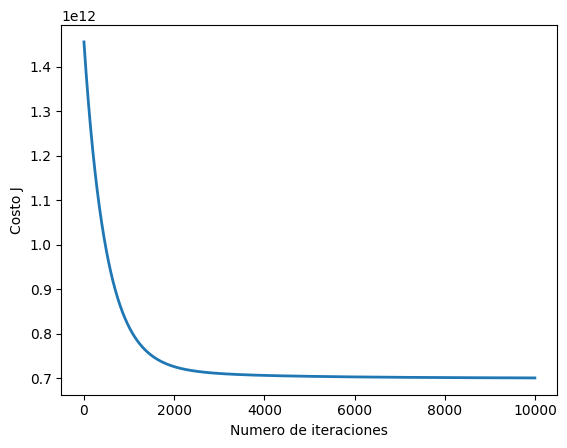

theta calculado por el descenso por el gradiente: [ 1.17177864e+06 -2.90957086e+05  1.55820946e+05 -1.03769183e+05
  9.19616050e+04  6.83491288e+02 -5.13315959e+04  1.62988643e+05
 -2.54908509e+05  1.15216638e+04  6.08090816e+04 -2.11749873e+05]


In [ ]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001 # alpha = 0.003
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])

# Ejecutar descenso de gradiente
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.show()

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

In [ ]:
# Probar datos:

X_array = [
    1,
    3,        # borough_x
    10001,    # zip_code
    1990,     # yearbuilt
    2000,     # lotarea
    1500,     # bldgarea
    1200,     # resarea
    0,        # comarea
    2,        # unitstotal
    2,        # numfloors
    40.7,     # latitude
    -73.9     # longitude
]

# Normalizar (excepto el 1)
X_array[1:] = (X_array[1:] - mu) / sigma

price = np.dot(X_array, theta)

print("Precio predicho:", price)

Precio predicho: 783264.2907918522
